In [59]:
"""
Single-digit CNN for gas-meter reading recognition -- following the paper's
actual approach (Son, Park, Lee, Paik, 2019, IEIE Trans. Smart Processing &
Computing):

    1. Digit segmentation: split a 5-digit meter crop into 5 individual
       single-digit images (paper uses connected-component labeling for the
       meter-reading area and MSER for the ID area; this script implements a
       connected-component segmenter as a general-purpose stand-in for both).
    2. Number recognition: ONE CNN classifier with a single 10-way softmax
       output, applied separately to each segmented digit crop.

Honesty note: the paper's segmentation stage includes filtering (bilateral +
morphology), "exception processing," box-size filtering, a rescale step, and
non-maximum suppression -- with specific thresholds that are not published in
the paper's text. What's implemented below is a reasonable, inspectable
connected-component segmenter, NOT a verified reproduction of their exact
pipeline. Use `debug_show_segmentation()` on real samples from your dataset
before trusting it, and tune the constants under "SEGMENTATION CONFIG" if it
misses or merges digits on your images.

This replaces the previous 5-output-head model (gas_meter_cnn.py). If your
data_set_generator produces images where the 5 digits are touching, very
low-contrast, or rotated, connected-component segmentation will need real
tuning -- that's expected; it's exactly the problem the paper spent effort on.
"""

'\nSingle-digit CNN for gas-meter reading recognition -- following the paper\'s\nactual approach (Son, Park, Lee, Paik, 2019, IEIE Trans. Smart Processing &\nComputing):\n\n    1. Digit segmentation: split a 5-digit meter crop into 5 individual\n       single-digit images (paper uses connected-component labeling for the\n       meter-reading area and MSER for the ID area; this script implements a\n       connected-component segmenter as a general-purpose stand-in for both).\n    2. Number recognition: ONE CNN classifier with a single 10-way softmax\n       output, applied separately to each segmented digit crop.\n\nHonesty note: the paper\'s segmentation stage includes filtering (bilateral +\nmorphology), "exception processing," box-size filtering, a rescale step, and\nnon-maximum suppression -- with specific thresholds that are not published in\nthe paper\'s text. What\'s implemented below is a reasonable, inspectable\nconnected-component segmenter, NOT a verified reproduction of thei

In [50]:


import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split


In [51]:


# ========================= CONFIG =========================
NUM_DIGITS = 5
NUM_CLASSES = 10          # digits 0-9
DIGIT_HEIGHT = 32         # size each segmented single-digit crop is resized to
DIGIT_WIDTH = 32
BATCH_SIZE = 32
EPOCHS = 33

# ---- SEGMENTATION CONFIG (tune against your real images) ----
MIN_COMPONENT_AREA_FRAC = 0.01   # component must cover at least 1% of crop area to count as a digit
MAX_COMPONENT_AREA_FRAC = 0.60   # discard components that are implausibly large (merged digits / background)
BOX_PADDING_PX = 2               # padding added around each detected digit box before crop+resize


In [52]:


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomContrast(0.2),
])

In [53]:
# %%
# ========================= MODEL DEFINITION =========================

def vgg_block(x, filters, block_name):
    """
    Paired 3x3 convolutions per block following the VGG pattern.
    Extracts spatial features and applies regularized dropout.
    """
    # First Conv Layer in the block
    x = layers.Conv2D(filters, (3, 3), padding='same', name=f'{block_name}_conv1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Second Conv Layer in the block
    x = layers.Conv2D(filters, (3, 3), padding='same', name=f'{block_name}_conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Spatial dimension reduction
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)
    return x


def create_single_digit_model():
    """
    Creates a single-digit classifier network that ingests an input image,
    runs it through data augmentation, extracts features with VGG blocks,
    and maps it to a 10-way softmax output.
    """
    # Define entry shape (DIGIT_HEIGHT, DIGIT_WIDTH, 1)
    inputs = layers.Input(shape=(DIGIT_HEIGHT, DIGIT_WIDTH, 1))
    
    # 1. Apply data augmentation ONCE directly at the input layer
    x = data_augmentation(inputs)

    # 2. Sequential feature extraction using the VGG blocks
    x = vgg_block(x, 32, 'block1')
    x = vgg_block(x, 64, 'block2')

    # 3. Flatten and Dense Classification Head
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    # Final 10-way softmax layer for digits 0-9
    output = layers.Dense(NUM_CLASSES, activation='softmax', name='digit')(x)

    return models.Model(inputs=inputs, outputs=output)

## Phase 1 -- Pretrain on the single-digit dataset

Each image in this dataset shows exactly **one** digit, and the **first character of the filename** is its label (e.g. `7_sample003.png` -> label `7`).

**Check/adjust `SINGLE_DIGIT_DATASET_DIR` below before running** -- I don't know where this dataset actually lives on your machine, so I pointed it at a placeholder path.


In [54]:
# ========================= PHASE 1 CONFIG =========================
NOTEBOOK_DIR = os.path.abspath("")

# EDIT THIS to point at your folder of single-digit images.
SINGLE_DIGIT_DATASET_DIR = os.path.join(NOTEBOOK_DIR, "ziffer_resize")

PRETRAIN_EPOCHS = 35
PRETRAIN_VAL_SPLIT = 0.15          # fraction of the single-digit set held out for validation
PRETRAIN_WEIGHTS_PATH = "best.weights.h5"

print(f"Single-digit dataset dir exists: {os.path.exists(SINGLE_DIGIT_DATASET_DIR)}")


Single-digit dataset dir exists: True


In [55]:
# ========================= PHASE 1: AUTO-LABEL FROM FILENAME =========================
def load_single_digit_filepaths_and_labels(dataset_dir):
    """Scans dataset_dir for image files and derives each image's label from
    the FIRST CHARACTER of its filename. Any file whose first character isn't
    a digit 0-9 is skipped (with a count printed), rather than silently
    mislabeled -- check that count against how many files you expect."""
    valid_ext = (".png", ".jpg", ".jpeg", ".bmp")
    filepaths, labels = [], []
    skipped = 0

    for fname in sorted(os.listdir(dataset_dir)):
        if not fname.lower().endswith(valid_ext):
            continue
        first_char = fname[0]
        if not first_char.isdigit():
            skipped += 1
            continue
        filepaths.append(os.path.join(dataset_dir, fname))
        labels.append(int(first_char))

    print(f"Found {len(filepaths)} labeled single-digit images "
          f"(skipped {skipped} files whose name didn't start with a digit 0-9).")
    return filepaths, labels


In [56]:
# ========================= PHASE 1: LOAD + PREPROCESS IMAGES =========================
def load_and_preprocess_digit_image(filepath, target_size=(DIGIT_HEIGHT, DIGIT_WIDTH)):
    gray_img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)
    if gray_img is None:
        return None
    gray_img = cv2.resize(gray_img, (target_size[1], target_size[0]))
    gray_img = gray_img.astype(np.float32) / 255.0
    return np.expand_dims(gray_img, axis=-1)


single_digit_paths, single_digit_labels = load_single_digit_filepaths_and_labels(SINGLE_DIGIT_DATASET_DIR)

X_pretrain, y_pretrain = [], []
for fp, lbl in zip(single_digit_paths, single_digit_labels):
    img = load_and_preprocess_digit_image(fp)
    if img is not None:
        X_pretrain.append(img)
        y_pretrain.append(lbl)

X_pretrain = np.stack(X_pretrain, axis=0).astype(np.float32)
y_pretrain = np.array(y_pretrain, dtype=np.int64)
print(f"Pretrain images ready: {X_pretrain.shape}, labels: {y_pretrain.shape}")


Found 671 labeled single-digit images (skipped 0 files whose name didn't start with a digit 0-9).
Pretrain images ready: (671, 32, 32, 1), labels: (671,)


In [57]:
# ========================= PHASE 1: TRAIN/VAL SPLIT =========================
X_pre_train, X_pre_val, y_pre_train, y_pre_val = train_test_split(
    X_pretrain, y_pretrain,
    test_size=PRETRAIN_VAL_SPLIT,
    stratify=y_pretrain,
    random_state=42,
)

pretrain_train_ds = tf.data.Dataset.from_tensor_slices((X_pre_train, y_pre_train)) \
    .shuffle(2048).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
pretrain_val_ds = tf.data.Dataset.from_tensor_slices((X_pre_val, y_pre_val)) \
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Pretrain split -> train: {len(X_pre_train)} | val: {len(X_pre_val)}")


Pretrain split -> train: 570 | val: 101


In [58]:
# ========================= PHASE 1: TRAIN + SAVE WEIGHTS =========================
pretrain_model = create_single_digit_model()

pretrain_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

pretrain_callbacks = [
    EarlyStopping(monitor='val_loss', patience=9, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1),
]

In [14]:


pretrain_history = pretrain_model.fit(
    pretrain_train_ds,
    validation_data=pretrain_val_ds,
    epochs=PRETRAIN_EPOCHS,
    
)



Epoch 1/35


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


18/18 ━━━━━━━━━━━━━━━━━━━━ 13s 203ms/step - accuracy: 0.1474 - loss: 2.9959 - val_accuracy: 0.1386 - val_loss: 2.3456
Epoch 2/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - accuracy: 0.2509 - loss: 2.2566 - val_accuracy: 0.1188 - val_loss: 2.3732
Epoch 3/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - accuracy: 0.3386 - loss: 2.0180 - val_accuracy: 0.1386 - val_loss: 2.5149
Epoch 4/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step - accuracy: 0.4684 - loss: 1.5393 - val_accuracy: 0.1485 - val_loss: 2.6259
Epoch 5/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - accuracy: 0.5544 - loss: 1.2742 - val_accuracy: 0.1584 - val_loss: 2.6908
Epoch 6/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step - accuracy: 0.7105 - loss: 0.9155 - val_accuracy: 0.1881 - val_loss: 2.7140
Epoch 7/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 173ms/step - accuracy: 0.7544 - loss: 0.7409 - val_accuracy: 0.2376 - val_loss: 2.6398
Epoch 8/35
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step - accuracy: 0.7860 - loss: 0.6631 - val_accuracy: 0.2376 - val

In [15]:

pretrain_model.save_weights(PRETRAIN_WEIGHTS_PATH)
print(f"Saved pretrained weights to {PRETRAIN_WEIGHTS_PATH}")

Saved pretrained weights to best.weights.h5


## Phase 2 -- Fine-tune on the 5-digit meter dataset

Same model architecture as phase 1 (so the pretrained weights load cleanly), warm-started from the single-digit weights saved above instead of random init.


In [59]:
pretrain_model.load_weights("best.weights.h5")

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\saving\saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'adam_2', because it has 2 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [60]:

# ========================= PATHS =========================
NOTEBOOK_DIR = os.path.abspath("")
BASE_DIR = os.path.abspath(os.path.join(NOTEBOOK_DIR, "..", "data_set_generator_for_cnns_only", "data_set"))

TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train")
VALID_IMG_DIR = os.path.join(BASE_DIR, "valid")
TEST_IMG_DIR = os.path.join(BASE_DIR, "test")

TRAIN_CSV = os.path.join(BASE_DIR, "train.csv")
VALID_CSV = os.path.join(BASE_DIR, "valid.csv")
TEST_CSV = os.path.join(BASE_DIR, "test.csv")


print("Checking paths...")
print(f"Train CSV exists: {os.path.exists(TRAIN_CSV)}")
print(f"Train Image Directory exists: {os.path.exists(TRAIN_IMG_DIR)}")
print(f"Valid CSV exists: {os.path.exists(VALID_CSV)}")
print(f"Valid Image Directory exists: {os.path.exists(VALID_IMG_DIR)}")
print(f"Test CSV exists: {os.path.exists(TEST_CSV)}")
print(f"Test Image Directory exists: {os.path.exists(TEST_IMG_DIR)}")

Checking paths...
Train CSV exists: True
Train Image Directory exists: True
Valid CSV exists: True
Valid Image Directory exists: True
Test CSV exists: True
Test Image Directory exists: True


In [61]:
# ========================= CSV CLEANING =========================
def clean_csv_by_removing_missing_images(csv_path, img_dir, split_name="Dataset"):
    print(f"=== Cleaning {split_name.upper()} Split ===")
    if not os.path.exists(csv_path):
        print(f"Skipping {split_name}: CSV file does not exist at {csv_path}\n")
        return
    if not os.path.exists(img_dir):
        print(f"Skipping {split_name}: Image directory does not exist at {img_dir}\n")
        return

    df = pd.read_csv(csv_path)
    original_row_count = len(df)
    image_exists_mask = df['image'].apply(lambda x: os.path.exists(os.path.join(img_dir, str(x))))
    cleaned_df = df[image_exists_mask]
    removed_rows_count = original_row_count - len(cleaned_df)
    cleaned_df.to_csv(csv_path, index=False)

    print(f"Original rows in CSV: {original_row_count}")
    print(f"Removed {removed_rows_count} rows because their images were missing.")
    print(f"Saved cleaned CSV with {len(cleaned_df)} remaining rows.")
    print("-" * 40 + "\n")


clean_csv_by_removing_missing_images(TRAIN_CSV, TRAIN_IMG_DIR, "Train")
clean_csv_by_removing_missing_images(VALID_CSV, VALID_IMG_DIR, "Validation")
clean_csv_by_removing_missing_images(TEST_CSV, TEST_IMG_DIR, "Test")


=== Cleaning TRAIN Split ===
Original rows in CSV: 1535
Removed 0 rows because their images were missing.
Saved cleaned CSV with 1535 remaining rows.
----------------------------------------

=== Cleaning VALIDATION Split ===
Original rows in CSV: 200
Removed 0 rows because their images were missing.
Saved cleaned CSV with 200 remaining rows.
----------------------------------------

=== Cleaning TEST Split ===
Original rows in CSV: 212
Removed 0 rows because their images were missing.
Saved cleaned CSV with 212 remaining rows.
----------------------------------------



In [62]:


# ========================= LOAD DATA (FAIL-SAFE) =========================
print("Loading datasets safely...")
df_train = pd.read_csv(TRAIN_CSV)
df_valid = pd.read_csv(VALID_CSV)
df_test = pd.read_csv(TEST_CSV)

for name, df, img_dir in [("train", df_train, TRAIN_IMG_DIR),
                           ("valid", df_valid, VALID_IMG_DIR),
                           ("test", df_test, TEST_IMG_DIR)]:
    mask = df['image'].apply(lambda x: os.path.exists(os.path.join(img_dir, str(x))))
    missing = len(df) - mask.sum()
    if missing > 0:
        print(f"Warning: {missing} rows in {name}.csv don't have matching files on disk. Skipping them.")

df_train = df_train[df_train['image'].apply(lambda x: os.path.exists(os.path.join(TRAIN_IMG_DIR, str(x))))]
df_valid = df_valid[df_valid['image'].apply(lambda x: os.path.exists(os.path.join(VALID_IMG_DIR, str(x))))]
df_test = df_test[df_test['image'].apply(lambda x: os.path.exists(os.path.join(TEST_IMG_DIR, str(x))))]

df_train['label'] = df_train['label'].astype(int)
df_valid['label'] = df_valid['label'].astype(int)
df_test['label'] = df_test['label'].astype(int)

print(f"\nFinal Ready Samples -> Train: {len(df_train)} | Val: {len(df_valid)} | Test: {len(df_test)}")


Loading datasets safely...

Final Ready Samples -> Train: 1535 | Val: 200 | Test: 212


In [63]:

# ========================= DIGIT SEGMENTATION =========================
def _binarize_for_segmentation(gray_img):
    """Denoise + threshold so digit strokes end up as white (255) on a
    black (0) background, regardless of the original polarity."""
    denoised = cv2.bilateralFilter(gray_img, d=5, sigmaColor=50, sigmaSpace=50)
    _, binary = cv2.threshold(denoised, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Otsu doesn't know which side is "foreground". Assume digit strokes are
    # the minority of pixels (true for most meter/ID crops); if white pixels
    # are the majority, the polarity is inverted, so flip it.
    if np.mean(binary == 255) > 0.5:
        binary = cv2.bitwise_not(binary)

    # Morphological close to bridge small gaps within a single digit's strokes.
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    return binary


In [64]:
def segment_digit_boxes(gray_img, num_digits=NUM_DIGITS):
    """Returns a list of `num_digits` (x, y, w, h) boxes, left-to-right,
    one per digit. Falls back to equal-width slicing if connected-component
    analysis doesn't cleanly find `num_digits` plausible components --
    this fallback is a safety net, not a substitute for correct segmentation;
    check debug_show_segmentation() on real samples to see how often it fires."""
    h_img, w_img = gray_img.shape[:2]
    img_area = h_img * w_img

    binary = _binarize_for_segmentation(gray_img)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    boxes = []
    for label_id in range(1, num_labels):  # skip background label 0
        x, y, w, h, area = stats[label_id]
        area_frac = area / img_area
        if MIN_COMPONENT_AREA_FRAC <= area_frac <= MAX_COMPONENT_AREA_FRAC:
            boxes.append((x, y, w, h))

    if len(boxes) == num_digits:
        boxes.sort(key=lambda b: b[0])  # left-to-right
        return boxes

    if len(boxes) > num_digits:
        # Keep the `num_digits` largest-area components, then re-sort by x.
        boxes.sort(key=lambda b: b[2] * b[3], reverse=True)
        boxes = boxes[:num_digits]
        boxes.sort(key=lambda b: b[0])
        return boxes

    # Fallback: connected components didn't find enough plausible digits
    # (e.g. touching digits, low contrast). Slice the crop into num_digits
    # equal-width columns instead. This is a crude fallback -- if it fires
    # often on your data, the segmentation constants above need tuning.
    col_width = w_img / num_digits
    return [(int(i * col_width), 0, int(col_width), h_img) for i in range(num_digits)]

In [65]:
def extract_digit_crops(gray_img, num_digits=NUM_DIGITS,
                         target_size=(DIGIT_HEIGHT, DIGIT_WIDTH)):
    """Segments gray_img into num_digits single-digit crops, each resized to
    target_size and normalized to [0, 1], shape (H, W, 1)."""
    h_img, w_img = gray_img.shape[:2]
    boxes = segment_digit_boxes(gray_img, num_digits=num_digits)

    crops = []
    for (x, y, w, h) in boxes:
        x0 = max(0, x - BOX_PADDING_PX)
        y0 = max(0, y - BOX_PADDING_PX)
        x1 = min(w_img, x + w + BOX_PADDING_PX)
        y1 = min(h_img, y + h + BOX_PADDING_PX)

        crop = gray_img[y0:y1, x0:x1]
        if crop.size == 0:
            crop = np.zeros((target_size[0], target_size[1]), dtype=np.uint8)

        crop = cv2.resize(crop, (target_size[1], target_size[0]))
        crop = crop.astype(np.float32) / 255.0
        crops.append(np.expand_dims(crop, axis=-1))

    return crops


In [66]:

def debug_show_segmentation(image_path, num_digits=NUM_DIGITS):
    """Visualize segmentation boxes + the resulting crops for one image.
    Run this on a handful of real samples before training, to sanity-check
    that segmentation is actually cutting individual digits correctly."""
    gray_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    boxes = segment_digit_boxes(gray_img, num_digits=num_digits)
    crops = extract_digit_crops(gray_img, num_digits=num_digits)
    fig, axes = plt.subplots(1, num_digits + 1, figsize=(3 * (num_digits + 1), 3))
    boxed_img = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2BGR)
    for (x, y, w, h) in boxes:
        cv2.rectangle(boxed_img, (x, y), (x + w, y + h), (0, 255, 0), 1)
    axes[0].imshow(boxed_img)
    axes[0].set_title("Detected boxes")
    axes[0].axis('off')
    for i, crop in enumerate(crops):
        axes[i + 1].imshow(crop.squeeze(), cmap='gray')
        axes[i + 1].set_title(f"digit slot {i+1}")
        axes[i + 1].axis('off')
    plt.tight_layout()
    plt.show()

In [27]:
# ========================= BUILD PER-DIGIT DATASETS =========================
def build_digit_dataset(df, img_dir, num_digits=NUM_DIGITS):
    """Runs segmentation over every row in df and returns:
        X: float32 array of shape (N * num_digits, H, W, 1)
        y: int array of shape (N * num_digits,)          -- single digit labels
        group_ids: int array of shape (N * num_digits,)  -- which original
                   row each crop came from, so full-number accuracy can be
                   reconstructed later (crops from the same row are adjacent
                   and in left-to-right digit order).
    """
    X, y, group_ids = [], [], []

    for group_id, (_, row) in enumerate(df.iterrows()):
        img_path = os.path.join(img_dir, str(row['image']))
        gray_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if gray_img is None:
            continue

        padded_label = str(int(row['label'])).zfill(num_digits)
        crops = extract_digit_crops(gray_img, num_digits=num_digits)

        for digit_char, crop in zip(padded_label, crops):
            X.append(crop)
            y.append(int(digit_char))
            group_ids.append(group_id)

    X = np.stack(X, axis=0).astype(np.float32)
    y = np.array(y, dtype=np.int64)
    group_ids = np.array(group_ids, dtype=np.int64)
    return X, y, group_ids


print("Segmenting training images into individual digits...")
X_train, y_train, _ = build_digit_dataset(df_train, TRAIN_IMG_DIR)
print(f"Train digit crops: {X_train.shape[0]}")

print("Segmenting validation images into individual digits...")
X_valid, y_valid, _ = build_digit_dataset(df_valid, VALID_IMG_DIR)
print(f"Valid digit crops: {X_valid.shape[0]}")

print("Segmenting test images into individual digits...")
X_test, y_test, test_group_ids = build_digit_dataset(df_test, TEST_IMG_DIR)
print(f"Test digit crops: {X_test.shape[0]}")

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(2048).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_valid, y_valid)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


Segmenting training images into individual digits...
Train digit crops: 7675
Segmenting validation images into individual digits...
Valid digit crops: 1000
Segmenting test images into individual digits...
Test digit crops: 1060


In [28]:
# ========================= PHASE 2: MODEL INSTANTIATION (warm-started) =========================
model = create_single_digit_model()

if os.path.exists(PRETRAIN_WEIGHTS_PATH):
    model.load_weights(PRETRAIN_WEIGHTS_PATH)
    print(f"Loaded pretrained weights from {PRETRAIN_WEIGHTS_PATH} -- "
          f"phase 2 will fine-tune from the single-digit-pretrained model.")
else:
    print(f"No pretrained weights found at {PRETRAIN_WEIGHTS_PATH} -- "
          f"training this model from scratch instead. Run the phase-1 cells above first "
          f"if you want the transfer-learning warm start.")

model.summary()


Loaded pretrained weights from best.weights.h5 -- phase 2 will fine-tune from the single-digit-pretrained model.


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 591,978 (2.26 MB)

 Trainable params: 591,338 (2.26 MB)

 Non-trainable params: 640 (2.50 KB)

In [29]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=9, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
]

In [43]:
history = model.fit(
    train_ds,
    validation_data=val_ds,

    initial_epoch=65,
    epochs=80,
    callbacks=callbacks
    
    
)

Epoch 66/80


199/199 ━━━━━━━━━━━━━━━━━━━━ 40s 199ms/step - accuracy: 0.8772 - loss: 0.5341 - val_accuracy: 0.7861 - val_loss: 0.9780 - learning_rate: 0.0010
Epoch 67/80
199/199 ━━━━━━━━━━━━━━━━━━━━ 35s 177ms/step - accuracy: 0.8772 - loss: 0.5411 - val_accuracy: 0.7988 - val_loss: 0.9687 - learning_rate: 0.0010
Epoch 68/80
199/199 ━━━━━━━━━━━━━━━━━━━━ 35s 176ms/step - accuracy: 0.8819 - loss: 0.5386 - val_accuracy: 0.8046 - val_loss: 0.9595 - learning_rate: 0.0010
Epoch 69/80
199/199 ━━━━━━━━━━━━━━━━━━━━ 37s 187ms/step - accuracy: 0.8751 - loss: 0.5481 - val_accuracy: 0.7792 - val_loss: 1.0446 - learning_rate: 0.0010
Epoch 70/80
199/199 ━━━━━━━━━━━━━━━━━━━━ 36s 181ms/step - accuracy: 0.8805 - loss: 0.5232 - val_accuracy: 0.7908 - val_loss: 0.9864 - learning_rate: 0.0010
Epoch 71/80
199/199 ━━━━━━━━━━━━━━━━━━━━ 31s 156ms/step - accuracy: 0.8813 - loss: 0.5355 - val_accuracy: 0.8035 - val_loss: 0.9706 - learning_rate: 0.0010
Epoch 72/80
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.8759 - 

In [45]:

# ========================= SAVE =========================
model.save("custom_q.keras")
print("Training completed and model saved.")

Training completed and model saved.


In [30]:
model = tf.keras.models.load_model("custom_q.keras", compile=False)



In [31]:
# ========================= EVALUATION (paper-style reporting) =========================
def evaluate_full():
    """Per-digit accuracy (like the paper's Table 3/4) AND full-5-digit
    exact-match accuracy reconstructed from grouped crops (like Table 5).
    """
    preds = model.predict(X_test, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    per_digit_acc = np.mean(pred_labels == y_test)
    print(f"\nSingle-digit accuracy across all positions: {per_digit_acc * 100:.2f}%")
    

    # per-class (0-9) breakdown, mirroring the paper's per-digit-value tables
    for digit_class in range(NUM_CLASSES):
        class_mask = y_test == digit_class
        if class_mask.sum() == 0:
            continue
        class_acc = np.mean(pred_labels[class_mask] == digit_class)
        print(f"  class {digit_class}: {class_mask.sum()} samples, accuracy {class_acc * 100:.2f}%")

    # Reconstruct full-number exact match using group_ids (5 consecutive
    # crops per original image, already in left-to-right order).
    num_groups = test_group_ids.max() + 1
    exact_matches = 0
    for g in range(num_groups):
        idx = np.where(test_group_ids == g)[0]
        if len(idx) != NUM_DIGITS:
            continue  # skip incomplete groups (shouldn't normally happen)
        if np.array_equal(pred_labels[idx], y_test[idx]):
            exact_matches += 1
    exact_match_acc = exact_matches / num_groups
    print(f"Full 5-digit exact-match accuracy: {exact_match_acc * 100:.2f}%")

    return per_digit_acc, exact_match_acc


evaluate_full()


Single-digit accuracy across all positions: 76.32%
  class 0: 326 samples, accuracy 93.56%
  class 1: 91 samples, accuracy 75.82%
  class 2: 112 samples, accuracy 73.21%
  class 3: 90 samples, accuracy 73.33%
  class 4: 72 samples, accuracy 55.56%
  class 5: 89 samples, accuracy 71.91%
  class 6: 64 samples, accuracy 68.75%
  class 7: 70 samples, accuracy 62.86%
  class 8: 73 samples, accuracy 64.38%
  class 9: 73 samples, accuracy 65.75%
Full 5-digit exact-match accuracy: 56.60%


(np.float64(0.7632075471698113), np.float64(0.5660377358490566))

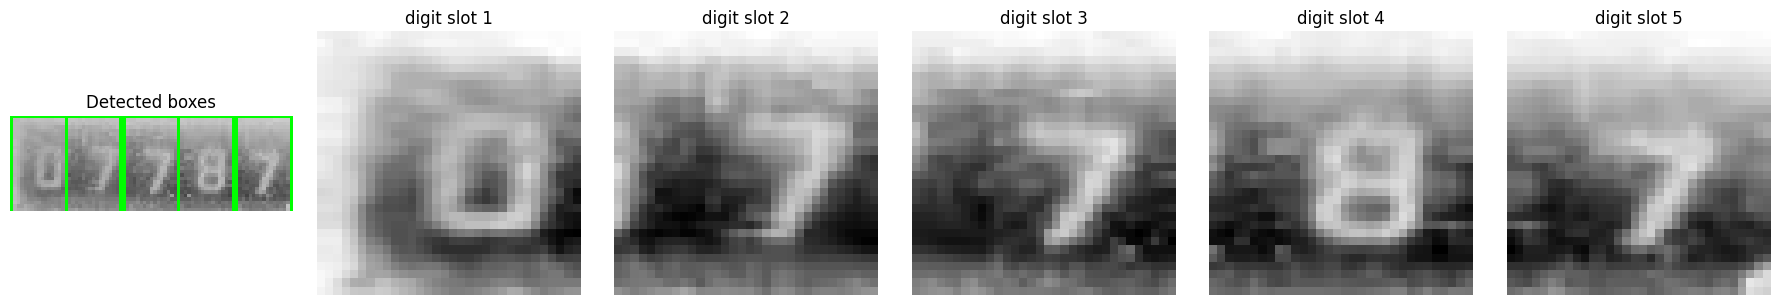

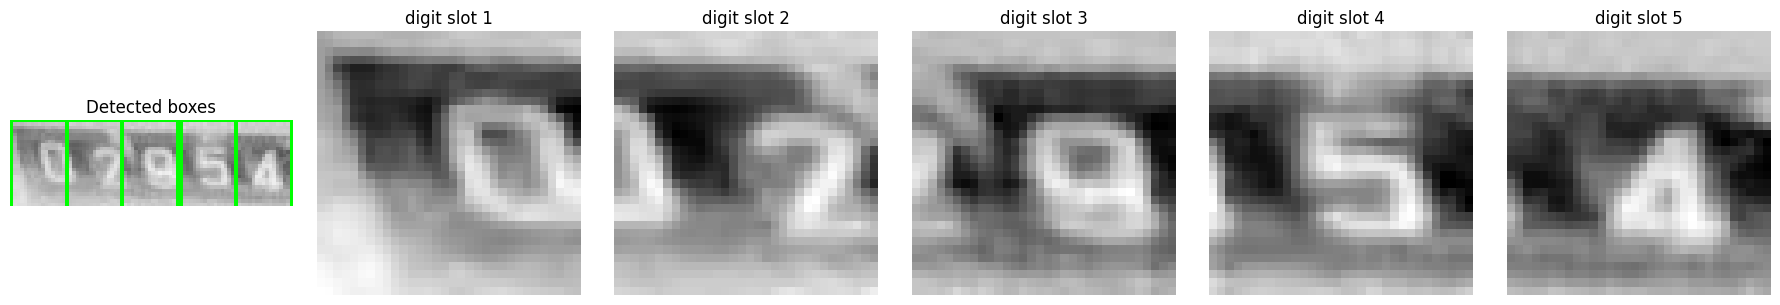

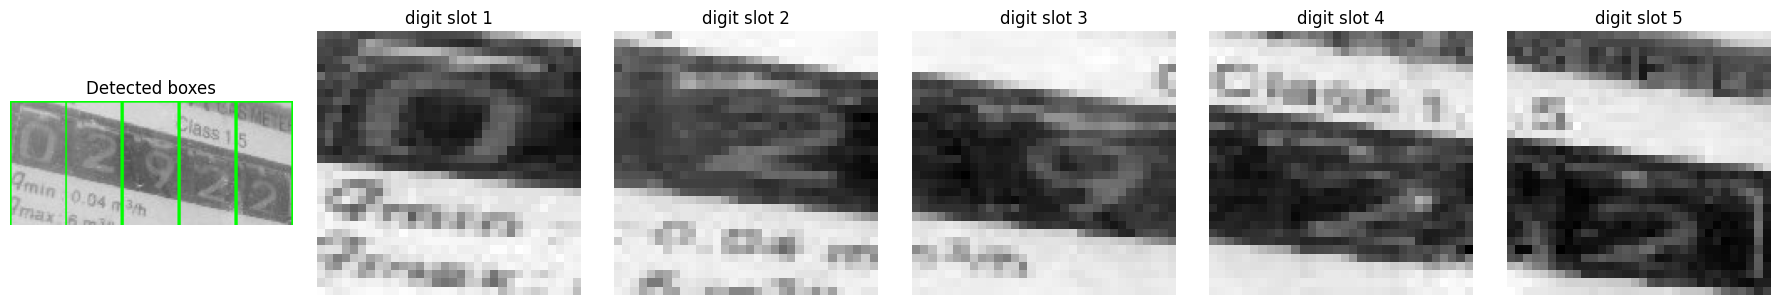

In [ ]:



# ========================= FULL METER-READING INFERENCE =========================
def read_meter(image_path, num_digits=NUM_DIGITS):
    """Runs the full paper-style pipeline on one image: segment into
    num_digits crops, classify each crop independently with the single
    shared model, concatenate into the final reading."""
    gray_img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if gray_img is None:
        raise FileNotFoundError(f"Missing file: {image_path}")

    crops = extract_digit_crops(gray_img, num_digits=num_digits)
    batch = np.stack(crops, axis=0)  # (num_digits, H, W, 1) -- one batched call, not 5 separate ones

    preds = model.predict(batch, verbose=0)
    digit_predictions = np.argmax(preds, axis=1)
    confidences = np.max(preds, axis=1) * 100

    final_reading = "".join(str(d) for d in digit_predictions)

    fig, axes = plt.subplots(1, num_digits + 1, figsize=(3 * (num_digits + 1), 3))
    axes[0].imshow(gray_img, cmap='gray')
    axes[0].set_title(f"Reading: {final_reading}")
    axes[0].axis('off')

    for i, crop in enumerate(crops):
        axes[i + 1].imshow(crop.squeeze(), cmap='gray')
        axes[i + 1].set_title(f"{digit_predictions[i]} ({confidences[i]:.0f}%)")
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()

    return final_reading, confidences
    plt.tight_layout()
image="74590510009_crop_0.png"
image1="87876420008_crop_0.png"
image2="94035910002_crop_0.png"
#5293420005_0
#0642_10208310002_crop_0
#0642_11608310006_crop_0
#0642_04481372763crop_0
#0642_09208310004crop_0

# Example usage:
debug_show_segmentation(os.path.join(TEST_IMG_DIR, image))  # check segmentation first


debug_show_segmentation(os.path.join(TEST_IMG_DIR, image1))  # check segmentation first




debug_show_segmentation(os.path.join(TEST_IMG_DIR, image2))  # check segmentation first




Showing segmentation for: 83669121408_crop_0.png


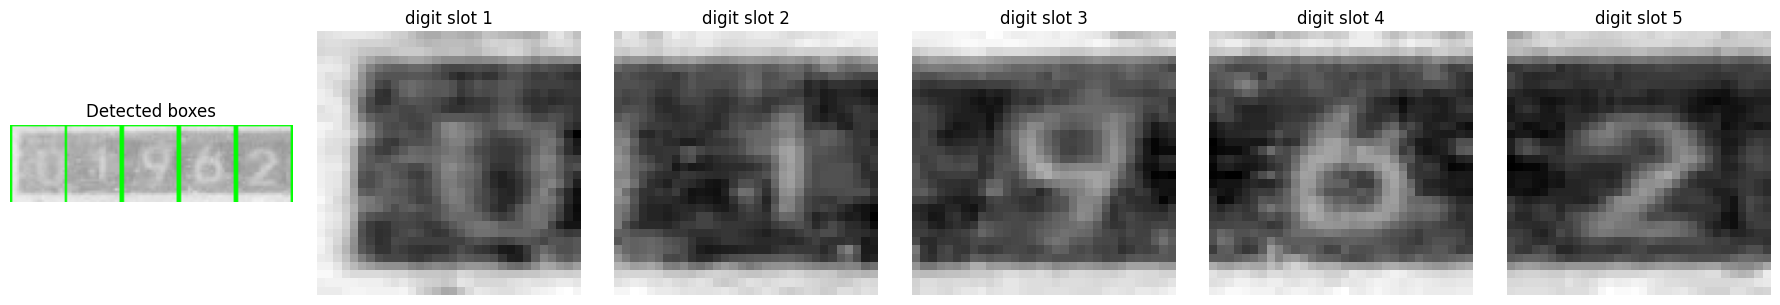

Showing segmentation for: 75161710001_crop_0.png


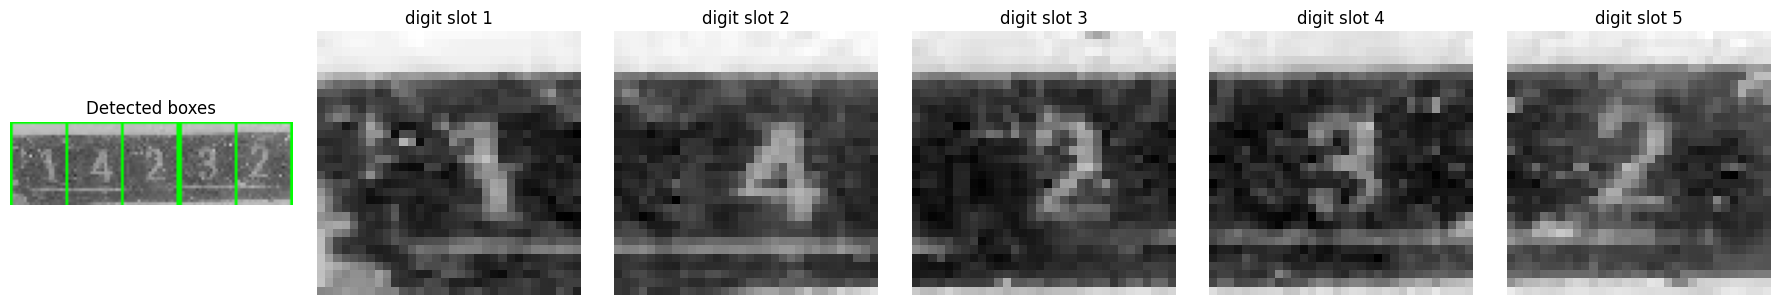

Showing segmentation for: 83245601105_crop_0.png


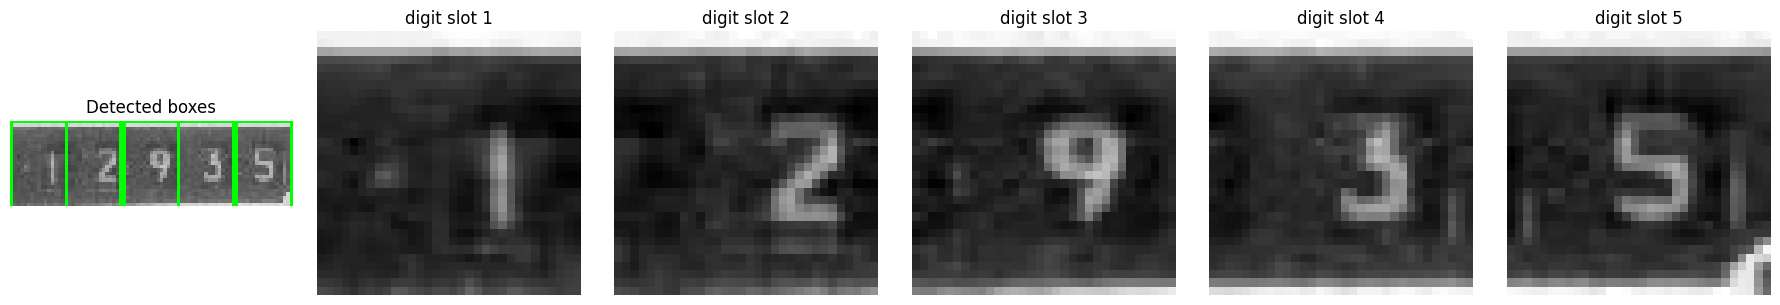

Showing segmentation for: 0642_12433557928_crop_0.png


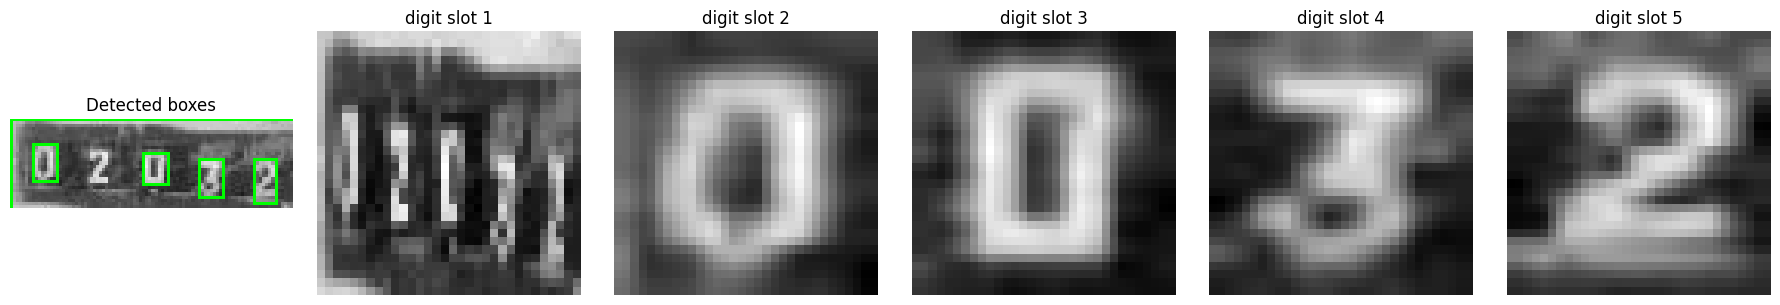

Showing segmentation for: 86416746450_crop_0.png


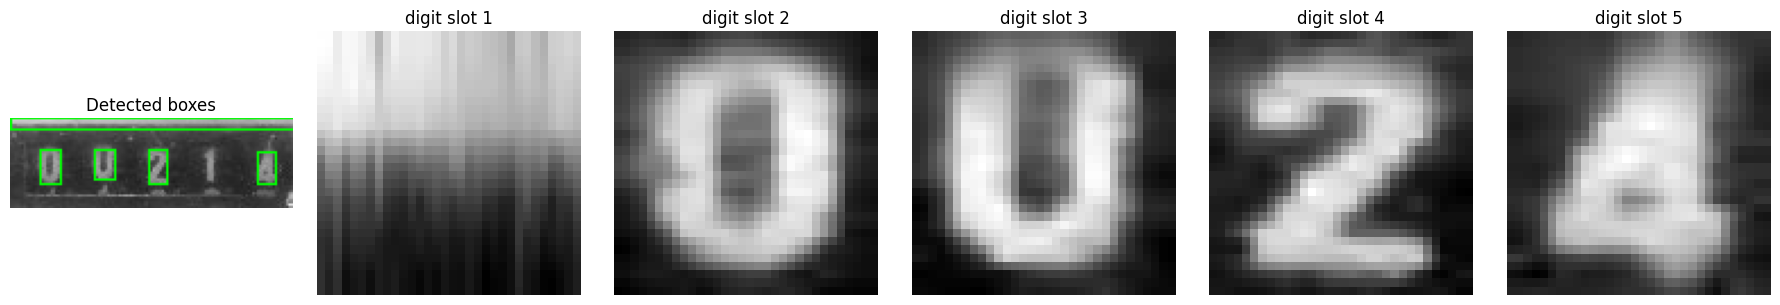

Showing segmentation for: 80422520009_crop_0.png


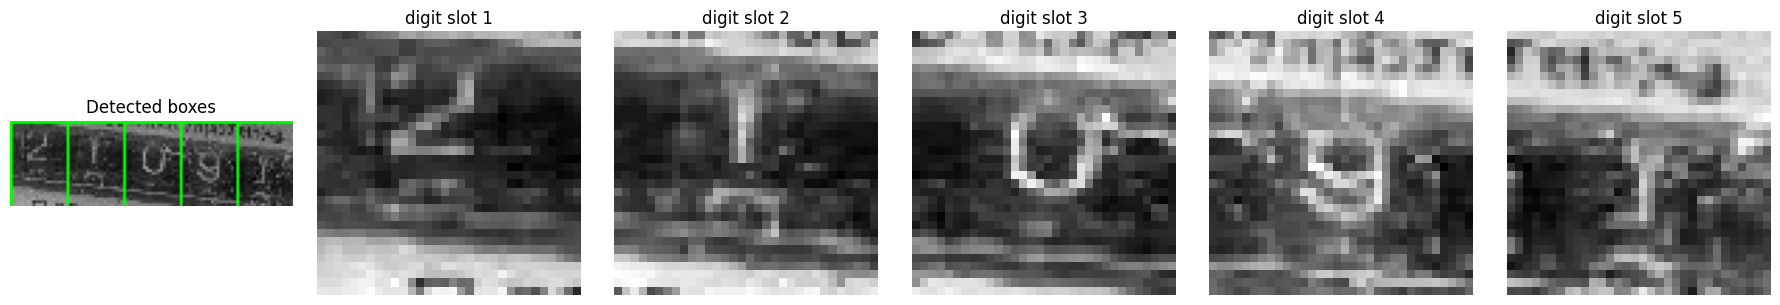

In [67]:
import os
import random

# Select 6 random images from the test folder
random_images = random.sample(
    [f for f in os.listdir(TEST_IMG_DIR)
     if f.lower().endswith((".png", ".jpg", ".jpeg"))],
    6
)

# Show only segmentation for each image
for img_name in random_images:
    print(f"Showing segmentation for: {img_name}")
    debug_show_segmentation(os.path.join(TEST_IMG_DIR, img_name))

In [ ]:

# # ========================= SAVE =========================
# model.save("custom.keras")
# print("Training completed and model saved.")

Training completed and model saved.


In [ ]:
# from tensorflow.keras import models

# model = models.load_model("custom.keras")

In [ ]:
# ========================= LIVE CAMERA METER READING =========================
import cv2

def select_roi_from_camera(camera_index=0):
    """Grabs one frame and lets you drag a box around the meter's digit strip.
    Press ENTER/SPACE to confirm, 'c' to cancel. Returns (x, y, w, h)."""
    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open camera index {camera_index}")

    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise RuntimeError("Could not read a frame to select ROI from.")

    roi = cv2.selectROI("Select digit strip, then press ENTER", frame, showCrosshair=True)
    cv2.destroyAllWindows()
    return roi  # (x, y, w, h)


def live_read_meter(camera_index=0, num_digits=NUM_DIGITS, conf_threshold=50, roi=None):
    """Opens a live webcam feed, crops to `roi` (selecting it first if not given),
    runs digit segmentation + the trained model on each frame, and overlays the
    predicted reading with per-digit confidence. Press 'q' to quit."""
    if roi is None:
        roi = select_roi_from_camera(camera_index)
    x, y, w, h = [int(v) for v in roi]
    if w == 0 or h == 0:
        raise ValueError("Empty ROI selected -- try again and drag an actual box.")

    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open camera index {camera_index}")

    print("Live meter reading started. Press 'q' in the video window to quit.")

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame -- exiting.")
            break

        cropped = frame[y:y + h, x:x + w]
        gray_crop = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)

        try:
            crops = extract_digit_crops(gray_crop, num_digits=num_digits)
            if len(crops) == num_digits:
                batch = np.stack(crops, axis=0)
                preds = model.predict(batch, verbose=0)
                digit_predictions = np.argmax(preds, axis=1)
                confidences = np.max(preds, axis=1) * 100
                reading = "".join(str(d) for d in digit_predictions)
                avg_conf = confidences.mean()

                color = (0, 255, 0) if avg_conf >= conf_threshold else (0, 165, 255)
                cv2.putText(frame, f"Reading: {reading} ({avg_conf:.0f}%)",
                            (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, color, 2)
            else:
                cv2.putText(frame, "Segmentation failed - reposition meter",
                            (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
        except Exception as e:
            cv2.putText(frame, f"Error: {str(e)[:40]}",
                        (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 1)
        cv2.imshow("Live Gas Meter Reading", frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()


# Run it (uses your already-trained `model` from phase 2):
# live_read_meter(camera_index=0)


In [ ]:
select_roi_from_camera(camera_index=0)   # helper: drag a box once around the digit strip
live_read_meter(camera_index=0)          # main loop: opens webcam, detects, overlays reading

Live meter reading started. Press 'q' in the video window to quit.


In [24]:
# ========================= METRICS + SAVED PLOTS (YOLO-style) =========================
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    accuracy_score, classification_report
)

def _next_run_dir(base="runs/eval", prefix="exp"):
    """Mimics YOLO's runs/exp, runs/exp2, runs/exp3... behavior."""
    os.makedirs(base, exist_ok=True)
    i = 1
    while True:
        candidate = os.path.join(base, f"{prefix}{'' if i == 1 else i}")
        if not os.path.exists(candidate):
            os.makedirs(candidate)
            return candidate
        i += 1


def evaluate_and_save(model, X_test, y_test, test_group_ids,
                       num_classes=NUM_CLASSES, num_digits=NUM_DIGITS,
                       class_names=None, save_dir=None):
    """Runs inference, computes accuracy/precision/recall/F1/confusion matrix,
    and saves everything as images + a JSON summary, the way YOLO dumps
    confusion_matrix.png / results.png into runs/train/expN/."""
    if class_names is None:
        class_names = [str(i) for i in range(num_classes)]
    if save_dir is None:
        save_dir = _next_run_dir()
    os.makedirs(save_dir, exist_ok=True)

    # ---- Inference ----
    probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(probs, axis=1)

    # ---- Core metrics ----
    per_digit_acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average=None, labels=range(num_classes), zero_division=0)
    recall = recall_score(y_test, y_pred, average=None, labels=range(num_classes), zero_division=0)
    f1 = f1_score(y_test, y_pred, average=None, labels=range(num_classes), zero_division=0)

    precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)

    # ---- Full 5-digit exact-match accuracy (reconstructed from group_ids) ----
    num_groups = test_group_ids.max() + 1
    exact_matches = 0
    valid_groups = 0
    for g in range(num_groups):
        idx = np.where(test_group_ids == g)[0]
        if len(idx) != num_digits:
            continue
        valid_groups += 1
        if np.array_equal(y_pred[idx], y_test[idx]):
            exact_matches += 1
    exact_match_acc = exact_matches / valid_groups if valid_groups else 0.0

    # ---- Confusion matrices ----
    cm = confusion_matrix(y_test, y_pred, labels=range(num_classes))
    cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True).clip(min=1)

    # ---- Plot: raw confusion matrix ----
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(f"Confusion Matrix (counts) — digit accuracy {per_digit_acc*100:.2f}%")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(num_classes)); ax.set_xticklabels(class_names)
    ax.set_yticks(range(num_classes)); ax.set_yticklabels(class_names)
    for i in range(num_classes):
        for j in range(num_classes):
            val = cm[i, j]
            ax.text(j, i, str(val), ha="center", va="center",
                    color="white" if val > cm.max() / 2 else "black", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    cm_path = os.path.join(save_dir, "confusion_matrix.png")
    fig.savefig(cm_path, dpi=150)
    plt.close(fig)

    # ---- Plot: normalized confusion matrix ----
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_title("Confusion Matrix (row-normalized)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(num_classes)); ax.set_xticklabels(class_names)
    ax.set_yticks(range(num_classes)); ax.set_yticklabels(class_names)
    for i in range(num_classes):
        for j in range(num_classes):
            val = cm_norm[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    color="white" if val > 0.5 else "black", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    cm_norm_path = os.path.join(save_dir, "confusion_matrix_normalized.png")
    fig.savefig(cm_norm_path, dpi=150)
    plt.close(fig)

    # ---- Plot: per-class precision/recall/F1 bar chart ----
    x = np.arange(num_classes)
    width = 0.25
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width, precision, width, label="Precision")
    ax.bar(x, recall, width, label="Recall")
    ax.bar(x + width, f1, width, label="F1")
    ax.set_xticks(x); ax.set_xticklabels(class_names)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title("Per-digit Precision / Recall / F1")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    prf_path = os.path.join(save_dir, "precision_recall_f1.png")
    fig.savefig(prf_path, dpi=150)
    plt.close(fig)

    # ---- Plot: overall "results" summary (YOLO results.png style) ----
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    axes[0].bar(["Per-digit acc", "5-digit exact match"],
                [per_digit_acc, exact_match_acc],
                color=["#4C72B0", "#DD8452"])
    for i, v in enumerate([per_digit_acc, exact_match_acc]):
        axes[0].text(i, v + 0.02, f"{v*100:.2f}%", ha="center", fontweight="bold")
    axes[0].set_ylim(0, 1.1)
    axes[0].set_title("Overall Accuracy")
    axes[0].grid(axis="y", alpha=0.3)

    axes[1].bar(["Precision\n(macro)", "Recall\n(macro)", "F1\n(macro)"],
                [precision_macro, recall_macro, f1_macro],
                color=["#55A868", "#C44E52", "#8172B2"])
    for i, v in enumerate([precision_macro, recall_macro, f1_macro]):
        axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")
    axes[1].set_ylim(0, 1.1)
    axes[1].set_title("Macro-averaged Metrics")
    axes[1].grid(axis="y", alpha=0.3)

    fig.suptitle("Gas Meter CNN — Evaluation Summary")
    fig.tight_layout()
    results_path = os.path.join(save_dir, "results.png")
    fig.savefig(results_path, dpi=150)
    plt.close(fig)

    # ---- Text/JSON summary (like YOLO's results.csv / results.json) ----
    report_txt = classification_report(y_test, y_pred, target_names=class_names,
                                        zero_division=0)
    with open(os.path.join(save_dir, "classification_report.txt"), "w") as f:
        f.write(report_txt)

    summary = {
        "timestamp": datetime.now().isoformat(),
        "per_digit_accuracy": float(per_digit_acc),
        "full_5digit_exact_match_accuracy": float(exact_match_acc),
        "precision_macro": float(precision_macro),
        "recall_macro": float(recall_macro),
        "f1_macro": float(f1_macro),
        "per_class": {
            class_names[i]: {
                "precision": float(precision[i]),
                "recall": float(recall[i]),
                "f1": float(f1[i]),
                "support": int((y_test == i).sum()),
            } for i in range(num_classes)
        },
    }
    with open(os.path.join(save_dir, "metrics.json"), "w") as f:
        json.dump(summary, f, indent=2)

    print(f"Saved evaluation artifacts to: {save_dir}")
    print(f"  - {cm_path}")
    print(f"  - {cm_norm_path}")
    print(f"  - {prf_path}")
    print(f"  - {results_path}")
    print(f"  - classification_report.txt, metrics.json")
    print(f"\nPer-digit accuracy: {per_digit_acc*100:.2f}%")
    print(f"Full 5-digit exact-match accuracy: {exact_match_acc*100:.2f}%")
    print(f"Macro precision/recall/F1: {precision_macro:.3f} / {recall_macro:.3f} / {f1_macro:.3f}")

    return summary


# Run it — creates runs/eval/exp, runs/eval/exp2, ... each call, just like YOLO
summary = evaluate_and_save(model, X_test, y_test, test_group_ids)

Saved evaluation artifacts to: runs/eval\exp
  - runs/eval\exp\confusion_matrix.png
  - runs/eval\exp\confusion_matrix_normalized.png
  - runs/eval\exp\precision_recall_f1.png
  - runs/eval\exp\results.png
  - classification_report.txt, metrics.json

Per-digit accuracy: 76.32%
Full 5-digit exact-match accuracy: 56.60%
Macro precision/recall/F1: 0.756 / 0.705 / 0.727
